# Análise Exploratória — Indicador Criança Alfabetizada (Fase 3)

**Objetivo:** entender a base `FT_MACHINE_LEARNING` (camada Gold, reconstruída
localmente a partir dos microdados do INEP — Avaliação da Alfabetização
2024) antes de treinar o modelo supervisionado que prevê se um aluno será
considerado alfabetizado.

Esta análise segue os pontos exigidos no Tech Challenge: compreensão de
distribuições, padrões, correlações e formulação de hipóteses analíticas
que apoiem as decisões de modelagem — em especial o **tratamento de data
leakage**, que é o achado central desta EDA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.width", 140)

df = pd.read_csv("../data/gold/FT_MACHINE_LEARNING.csv", low_memory=False)
print(f"Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas")

Shape: 2,120,560 linhas x 45 colunas


## 1. Visão geral

In [2]:
print("Período coberto:", sorted(df['ANO_REFERENCIA'].unique()))
print("UFs:", df['SG_UF'].nunique(), "| Municípios:", df['CO_MUNICIPIO'].nunique())
print()
nulos = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
print("Top 12 colunas com mais valores nulos (%):")
print(nulos.head(12))

Período coberto: [np.int64(2024)]
UFs: 26 | Municípios: 5519

Top 12 colunas com mais valores nulos (%):
DIF_MEDIA_ESTADO                13.72
DESEMPENHO_RELATIVO             13.72
VL_PROFICIENCIA_LP              12.67
DIF_MEDIA_MUNICIPIO             12.67
VL_PESO_ALUNO_LP                12.67
DIF_ALFABETIZACAO_MUNICIPIO      1.45
VL_MEDIA_LP_ESTADO               1.31
PC_ALUNO_ALFABETIZADO_ESTADO     1.31
VL_MEDIA_LP                      0.15
FAIXA_ALFABETIZACAO              0.15
FAIXA_MEDIA_LP                   0.15
PC_ALUNO_ALFABETIZADO            0.15
dtype: float64


A base cobre a avaliação de 2024 em todos os estados. As colunas com mais
nulos são exatamente as ligadas à **proficiência do aluno**
(`VL_PROFICIENCIA_LP`, `DIF_MEDIA_*`, `VL_PESO_ALUNO_LP`) — o que já é o
primeiro sinal de que existe um grupo relevante de alunos que **não foi
avaliado** (ausentes ou com prova invalidada).

## 2. Distribuição do target (`IN_ALFABETIZADO`)

TARGET
0    47.79
1    52.21
Name: proportion, dtype: float64


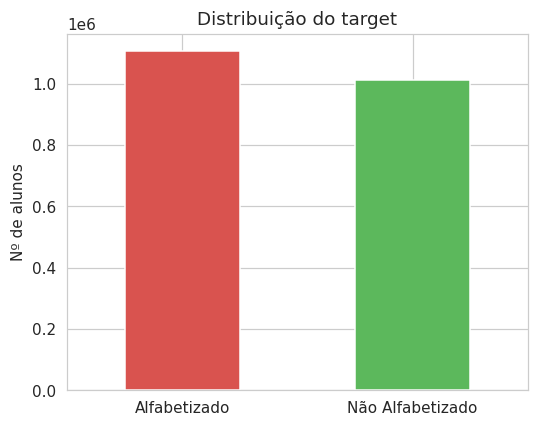

In [3]:
target_pct = df['TARGET'].value_counts(normalize=True).sort_index() * 100
print(target_pct.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
df['TARGET'].map({0: 'Não Alfabetizado', 1: 'Alfabetizado'}).value_counts().plot(
    kind='bar', color=['#d9534f', '#5cb85c'], ax=ax)
ax.set_title('Distribuição do target')
ax.set_xlabel('')
ax.set_ylabel('Nº de alunos')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

O target está **razoavelmente balanceado** (52,2% alfabetizados vs. 47,8%
não alfabetizados) — não há necessidade de técnicas de balanceamento
(SMOTE, undersampling) para a modelagem.

## 3. Participação na avaliação

In [4]:
print(df['DS_PARTICIPACAO'].value_counts())
print()
print("Entre quem NÃO foi avaliado, distribuição do target:")
print(df.loc[df['VL_PROFICIENCIA_LP'].isna(), 'TARGET'].value_counts())

DS_PARTICIPACAO
Participou        1851852
Não Participou     268708
Name: count, dtype: int64

Entre quem NÃO foi avaliado, distribuição do target:
TARGET
0    268708
Name: count, dtype: int64


**Achado importante:** os ~268 mil alunos sem proficiência registrada
(12,7% da base) recebem **automaticamente `TARGET = 0`** — ou seja, a
metodologia do INEP trata "não avaliado" como "não alfabetizado" por
definição. Isso é uma limitação conceitual do indicador (não necessariamente
o aluno não sabe ler — ele pode simplesmente não ter feito a prova), e deve
constar no README como limitação do projeto.

## 4. Distribuição da proficiência em Língua Portuguesa

count    1851852.0
mean         749.0
std           47.0
min          593.9
25%          720.5
50%          754.0
75%          780.4
max          900.9
Name: VL_PROFICIENCIA_LP, dtype: float64


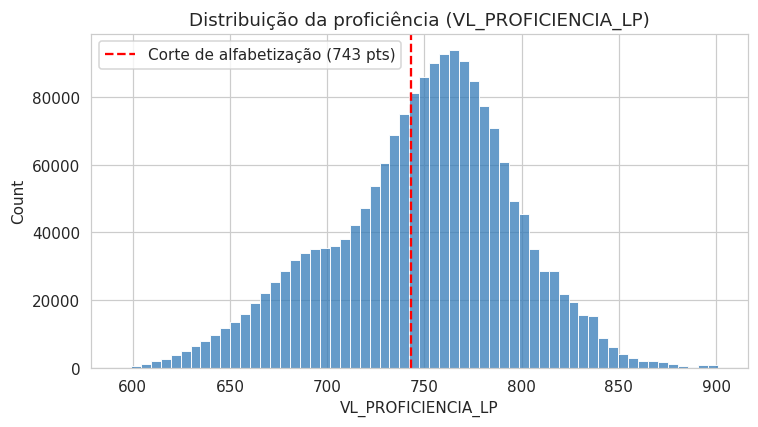

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df['VL_PROFICIENCIA_LP'].dropna(), bins=60, ax=ax, color='#337ab7')
ax.axvline(743, color='red', linestyle='--', label='Corte de alfabetização (743 pts)')
ax.set_title('Distribuição da proficiência (VL_PROFICIENCIA_LP)')
ax.legend()
plt.tight_layout()
plt.show()

print(df['VL_PROFICIENCIA_LP'].describe().round(1))

A distribuição é aproximadamente normal, centrada perto do próprio ponto
de corte (743), o que é esperado — o corte foi calibrado estatisticamente
pelo INEP para dividir a população de forma equilibrada.

## 5. Desigualdade regional e por rede de ensino

REGIAO
Centro-Oeste    57.5
Sudeste         54.8
Nordeste        52.4
Sul             49.1
Norte           42.2
Name: TARGET, dtype: float64

DS_DEPENDENCIA
Municipal    1840277
Estadual      280258
Privada           25
Name: count, dtype: int64


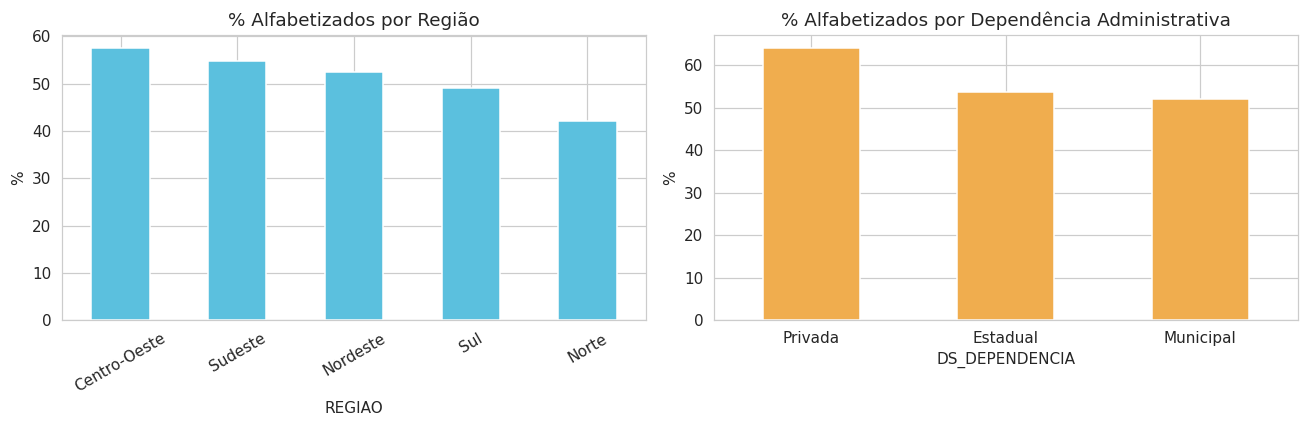

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

por_regiao = (df.groupby('REGIAO')['TARGET'].mean() * 100).sort_values(ascending=False)
por_regiao.plot(kind='bar', ax=axes[0], color='#5bc0de')
axes[0].set_title('% Alfabetizados por Região')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=30)

por_rede = (df.groupby('DS_DEPENDENCIA')['TARGET'].mean() * 100).sort_values(ascending=False)
por_rede.plot(kind='bar', ax=axes[1], color='#f0ad4e')
axes[1].set_title('% Alfabetizados por Dependência Administrativa')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(por_regiao.round(1))
print()
print(df['DS_DEPENDENCIA'].value_counts())

Existe uma diferença de **~15 pontos percentuais** entre a região com
melhor resultado (Centro-Oeste, 57,5%) e a pior (Norte, 42,2%) — confirma a
desigualdade educacional regional mencionada no problema de negócio do
desafio. Na rede, a amostra de escolas **Privadas é praticamente
inexistente (25 alunos)** — não deve ser tratada como conclusão
estatisticamente confiável, é só um efeito de a base do INEP cobrir
majoritariamente a rede pública (Municipal = 87% da base).

## 6. Correlação das variáveis numéricas com o target

IN_ACIMA_MEDIA_ESTADO           0.827
VL_PROFICIENCIA_LP              0.799
IN_ACIMA_MEDIA_MUNICIPIO        0.788
DIF_MEDIA_ESTADO                0.769
DIF_MEDIA_MUNICIPIO             0.742
PC_ALUNO_ALFABETIZADO           0.310
VL_MEDIA_LP                     0.299
PC_ALUNO_ALFABETIZADO_ESTADO    0.231
VL_MEDIA_LP_ESTADO              0.225
DIF_ALFABETIZACAO_MUNICIPIO    -0.209
Name: TARGET, dtype: float64


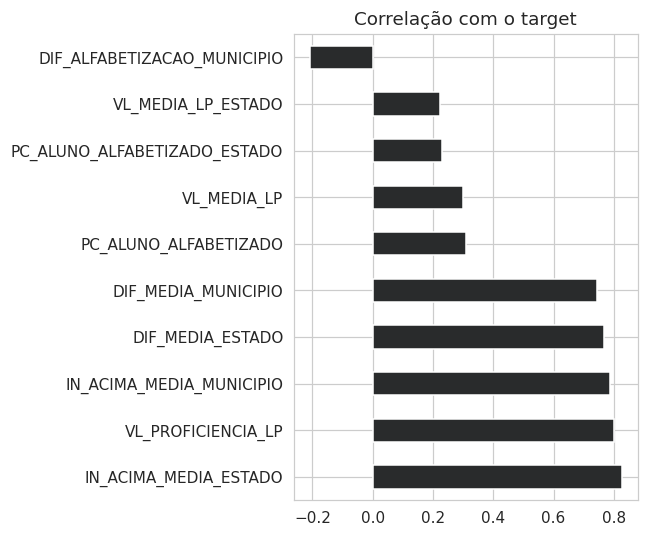

In [7]:
num_cols = [
    'VL_PROFICIENCIA_LP', 'DIF_MEDIA_MUNICIPIO', 'DIF_MEDIA_ESTADO',
    'IN_ACIMA_MEDIA_MUNICIPIO', 'IN_ACIMA_MEDIA_ESTADO',
    'PC_ALUNO_ALFABETIZADO', 'PC_ALUNO_ALFABETIZADO_ESTADO',
    'DIF_ALFABETIZACAO_MUNICIPIO', 'VL_MEDIA_LP', 'VL_MEDIA_LP_ESTADO',
]
corr = df[num_cols + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values(ascending=False)
print(corr.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
corr.plot(kind='barh', ax=ax, color='#292b2c')
ax.set_title('Correlação com o target')
plt.tight_layout()
plt.show()

Todas as variáveis derivadas de proficiência (`VL_PROFICIENCIA_LP`,
`DIF_MEDIA_*`, `IN_ACIMA_MEDIA_*`) têm correlação **muito alta** com o
target (0.74 a 0.80). Isso não é uma boa notícia para a modelagem — é o
gatilho para o achado da próxima seção.

## 7. Achado crítico: Data Leakage

O desafio pede explicitamente o **tratamento de data leakage** na pipeline.
A EDA mostra exatamente onde ele está: o próprio `TARGET` (`IN_ALFABETIZADO`)
é **matematicamente derivado** de `VL_PROFICIENCIA_LP`.

In [8]:
avaliados = df[df['VL_PROFICIENCIA_LP'].notna()]
print("Alunos avaliados com proficiência >= 743 x TARGET:")
print(pd.crosstab(avaliados['VL_PROFICIENCIA_LP'] >= 743, avaliados['TARGET']))

Alunos avaliados com proficiência >= 743 x TARGET:
TARGET                   0        1
VL_PROFICIENCIA_LP                 
False               744733        0
True                     0  1107119


**A tabela acima mostra 100% de correspondência, sem uma única exceção**:
todo aluno com `VL_PROFICIENCIA_LP >= 743` tem `TARGET = 1`, e todo aluno
abaixo tem `TARGET = 0`. Combinado com a Seção 3 (não avaliado → `TARGET =
0` sempre), isso prova que o target é **100% determinístico** a partir de
duas informações: participação na prova + nota de proficiência.

**Implicação direta para a modelagem:** as colunas abaixo não podem entrar
como features, sob risco de o modelo "prever" o target apenas reconstruindo
a regra de corte (acurácia artificial ~100%, sem nenhum valor preditivo
real):

- `VL_PROFICIENCIA_LP`, `FAIXA_PROFICIENCIA` — a nota em si e sua faixa
- `DIF_MEDIA_MUNICIPIO`, `DIF_MEDIA_ESTADO`, `IN_ACIMA_MEDIA_MUNICIPIO`, `IN_ACIMA_MEDIA_ESTADO`, `DESEMPENHO_RELATIVO` — todas calculadas a partir da nota
- `IN_PRESENCA_LP`, `IN_PREENCHIMENTO_LP`, `IN_PARTICIPOU_AVALIACAO`, `DS_PARTICIPACAO`, `DS_SITUACAO_AVALIACAO`, `IN_PROVA_VALIDA`, `IN_POSSUI_PROFICIENCIA`, `VL_PESO_ALUNO_LP` — determinam se o aluno foi avaliado, o que já fixa o target em 0 quando não foi
- `IN_ALFABETIZADO`, `DS_ALFABETIZADO` — o próprio target em outras formas

Há ainda um **vazamento parcial e mais sutil**: `PC_ALUNO_ALFABETIZADO`,
`PC_ALUNO_ALFABETIZADO_ESTADO`, `VL_MEDIA_LP`, `VL_MEDIA_LP_ESTADO` e
`FAIXA_ALFABETIZACAO`/`FAIXA_MEDIA_LP` são médias agregadas por
município/estado que **incluem o próprio aluno no cálculo** — o efeito é
pequeno em municípios grandes, mas relevante nos menores (a mediana é de
apenas 122 alunos por município). A decisão recomendada para a etapa de
modelagem é excluir essas colunas também, ou recalculá-las em esquema
*leave-one-out* (média do município excluindo o próprio aluno) caso se
queira mantê-las como proxy de contexto territorial.

## 8. Conclusões e hipóteses para a etapa de modelagem

**Features seguras para o modelo** (conhecidas antes da prova, sem relação
matemática com o resultado): `REGIAO`, `SG_UF`, `CO_UF`, `CO_MUNICIPIO`
(para enriquecimento externo via IBGE/Censo Escolar/PNAD), `TP_DEPENDENCIA`
/ `DS_DEPENDENCIA`, `ANO_REFERENCIA`.

**Features a excluir por data leakage direto:** toda a família ligada a
`VL_PROFICIENCIA_LP` e às flags de participação (listadas na Seção 7).

**Features a tratar com cautela (leakage parcial/agregado):**
`PC_ALUNO_ALFABETIZADO*`, `VL_MEDIA_LP*`, `FAIXA_ALFABETIZACAO`,
`FAIXA_MEDIA_LP`, `DIF_ALFABETIZACAO_MUNICIPIO`.

**Hipótese central a validar na modelagem:** como a maior parte do sinal
"legítimo" restante é territorial (região, UF, rede), o modelo provavelmente
vai precisar do **enriquecimento com fontes externas** (IBGE, Censo Escolar,
PNAD, Atlas do Desenvolvimento Humano) sugerido no enunciado — indicadores
socioeconômicos por município tendem a ser o principal driver preditivo
depois que as variáveis de leakage forem removidas.

**Limitação a registrar no README final:** o indicador trata "não avaliado"
como "não alfabetizado", o que mistura duas populações conceitualmente
diferentes (aluno que não aprendeu vs. aluno que não fez a prova).